<a href="https://colab.research.google.com/github/TanviAshokKadge/DS/blob/main/TCS025_Tanvi_Ashok_Kadge_DS_Pract_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical 7 - Decision classification on the titanic dataset**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
titanic_df=pd.read_csv('/content/train.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
features=['Pclass','Sex','Age','SibSp','Parch']
X=titanic_df[features]   # Independent variables
y=titanic_df['Survived']   # Target or dependent variable
X.head()

,Pclass,Sex,Age,SibSp,Parch
0,3,male,22.0,1,0
1,1,female,38.0,1,0
2,3,female,26.0,0,0
3,1,female,35.0,1,0
4,3,male,35.0,0,0


In [ ]:
y.info()
y.head()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
X['Age'].fillna(X['Age'].median(), inplace=True)

/tmp/ipython-input-668403536.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)


In [ ]:
X.isnull().sum()

,0
Pclass,0
Age,0
SibSp,0
Parch,0
Sex_male,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Initialize the Decision Tree Classifier
dtmodel=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=10)

# Train the model
dtmodel.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=10)

In [ ]:
Y_pred=dtmodel.predict(X_test)
accuracy=accuracy_score(y_test,Y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8379888268156425


In [ ]:
print(classification_report(y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       117
           1       0.77      0.76      0.76        62

    accuracy                           0.84       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



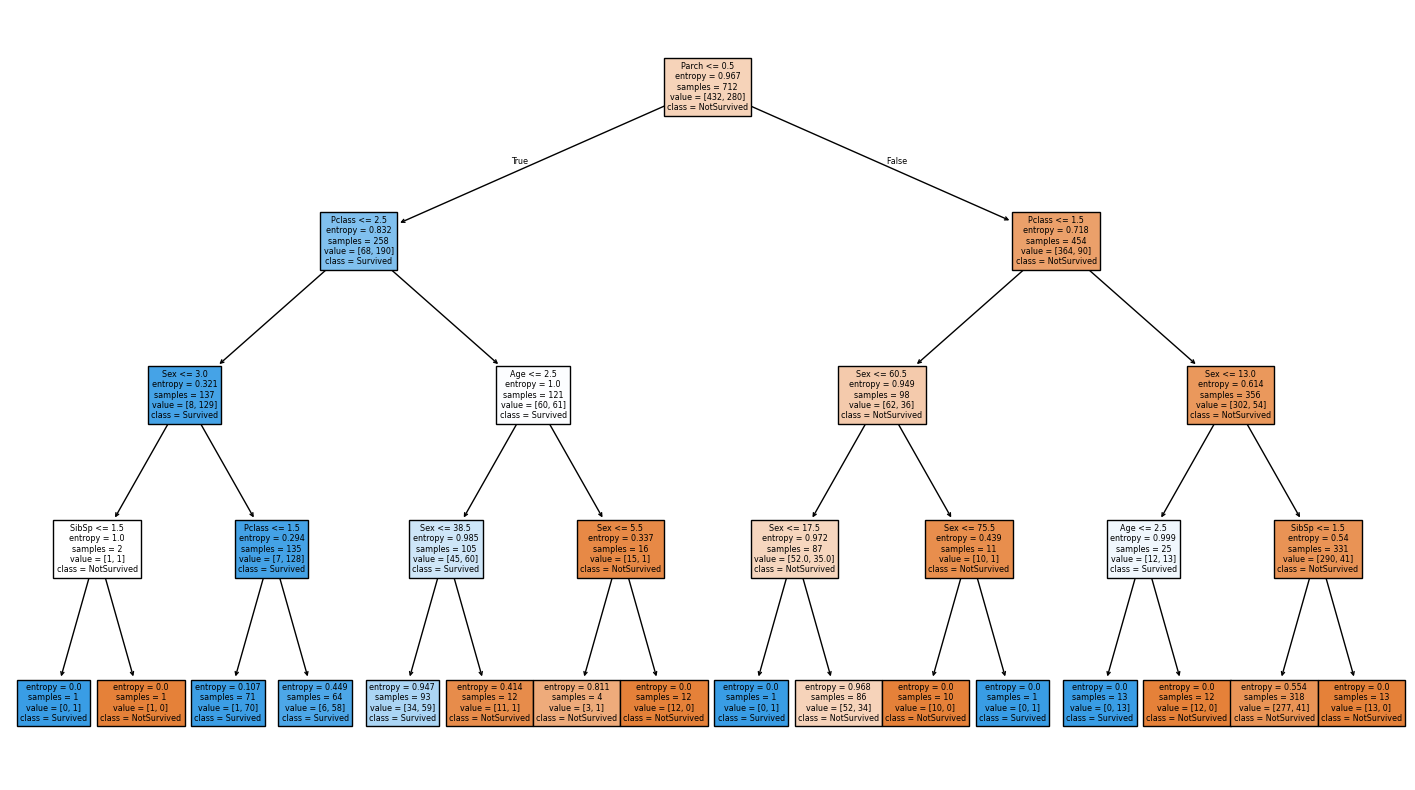

In [ ]:
plt.figure(figsize=(18,10))
plot_tree(dtmodel,feature_names=features,class_names=['NotSurvived','Survived'],filled=True)
plt.show()